# Grouping

In [1]:
import numpy as np
import pandas as pd

# Load Palmer penguins data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## Summary statistics

In [2]:
# Get the number of non-NA values in each column 
penguins.count()

species              344
island               344
bill_length_mm       342
bill_depth_mm        342
flipper_length_mm    342
body_mass_g          342
sex                  333
year                 344
dtype: int64

In [3]:
# Get minimum value in each column with numerical values
penguins.select_dtypes('number').min()

bill_length_mm         32.1
bill_depth_mm          13.1
flipper_length_mm     172.0
body_mass_g          2700.0
year                 2007.0
dtype: float64

## Grouping

General structure:

`df.groupby(columns_to_group_by).summary_method()`

In [5]:
penguins['flipper_length_mm'].mean()

200.91520467836258

In [6]:
# Mean flipper length by species. 
# First group by the species column values 
penguins.groupby('species')['flipper_length_mm']

In [7]:
# Average flipper length per species, chain on .mean()
penguins.groupby('species')['flipper_length_mm'].mean()

species
Adelie       189.953642
Chinstrap    195.823529
Gentoo       217.186992
Name: flipper_length_mm, dtype: float64

In [ ]:
# Average flipper length per species, renamed the column
# Similar to mutate in R
avg_flipper = (penguins.groupby('species')
                        ['flipper_length_mm']
                        .mean()
                        .rename('mean_flipper_length')
                        .sort_values(ascending=False)
                        )
avg_flipper

You can also group by two columns

In [8]:
# Average flipper length per species and island
avg_flipper_species_island = (penguins.groupby(['species','island'])
                                ['flipper_length_mm']
                                .mean()
                                .rename('mean_flipper_length')
                                .sort_values(ascending=False)
                                )
avg_flipper_species_island

species    island   
Gentoo     Biscoe       217.186992
Chinstrap  Dream        195.823529
Adelie     Torgersen    191.196078
           Dream        189.732143
           Biscoe       188.795455
Name: mean_flipper_length, dtype: float64

## Grouping and NA values


`size`: returns the number of observations in a pandas.Series
`count()`: returns the number of non-NA observations in the series


In [9]:
# Number of NA observations
penguins['sex'].size - penguins['sex'].count()

11

In [ ]:
# By default, groupby() leaves out rows where grouping column has NA values
penguins.groupby('sex').size()

In [10]:
# This is how you keep those NA values 
penguins.groupby('sex', dropna=False).size()

sex
female    165
male      168
NaN        11
dtype: int64

## Check-in

In [11]:
penguins.groupby(['island', 'year']).count()

species  bill_length_mm  bill_depth_mm  flipper_length_mm  \
island    year                                                              
Biscoe    2007       44              44             44                 44   
          2008       64              64             64                 64   
          2009       60              59             59                 59   
Dream     2007       46              46             46                 46   
          2008       34              34             34                 34   
          2009       44              44             44                 44   
Torgersen 2007       20              19             19                 19   
          2008       16              16             16                 16   
          2009       16              16             16                 16   

                body_mass_g  sex  
island    year                    
Biscoe    2007           44   43  
          2008           64   63  
          2009           59   57  
Dream     2007           46   45  
          2008           34   34  
          2009           44   44  
Torgersen 2007           19   15  
          2008           16   16  
          2009           16   16

In [13]:
type(penguins.groupby(['island', 'year']).count())

pandas.core.frame.DataFrame

In [16]:
penguins.groupby(['island', 'year']).size()

island     year
Biscoe     2007    44
           2008    64
           2009    60
Dream      2007    46
           2008    34
           2009    44
Torgersen  2007    20
           2008    16
           2009    16
dtype: int64

In [15]:
type(penguins.groupby(['island', 'year']).size())

pandas.core.series.Series

The differences in output is that 
the first code chunk using `.count()` returns a pandas data frame with the number of non-NA observations in the series (the `island` and `year` columns). The output provides all other variable values (e.g. `bill_length_mm`, `bill_depth_mm`, etc. )

The second code chunk using `size` returns a pandas series with simply the number of observations (number of rows in each column). It only returns the grouped values for the specified columns. It includes NA's as observations. 
(penguins.groupby(['island','year'])
         .size()
         .sort_values()
         .plot(kind='barh',
                title='Penguins surveyed at the Palmer Archipelago',
                xlabel='Number of penguins',
                ylabel='Island, Year')
         )


<Axes: title={'center': 'Penguins surveyed at the Palmer Archipelago'}, xlabel='Number of penguins', ylabel='Island, Year'>

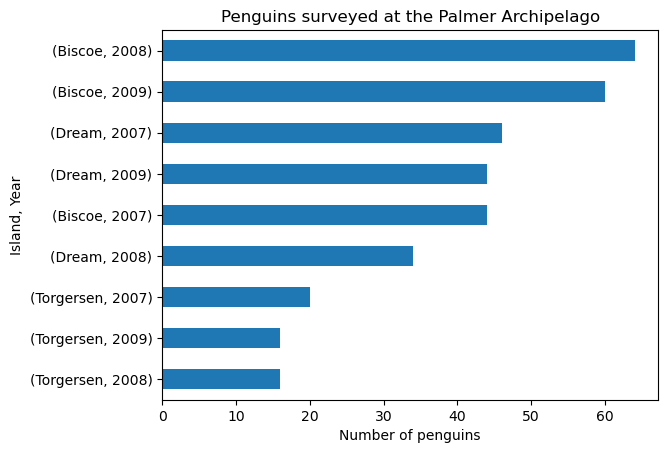

In [17]:
# Plot the surveyed population per year and island
(penguins.groupby(['island','year'])
         .size()
         .sort_values()
         .plot(kind='barh',
                title='Penguins surveyed at the Palmer Archipelago',
                xlabel='Number of penguins',
                ylabel='Island, Year')
         )

## Check-in

In [30]:
penguins.groupby(['year','species'])['body_mass_g'].max()

year  species  
2007  Adelie       4675.0
      Chinstrap    4400.0
      Gentoo       6300.0
2008  Adelie       4700.0
      Chinstrap    4800.0
      Gentoo       6000.0
2009  Adelie       4775.0
      Chinstrap    4450.0
      Gentoo       6000.0
Name: body_mass_g, dtype: float64

<Axes: title={'center': 'Highest penguin body masses (g) per year and species'}, xlabel='Body Mass (g)', ylabel='Year, Species'>

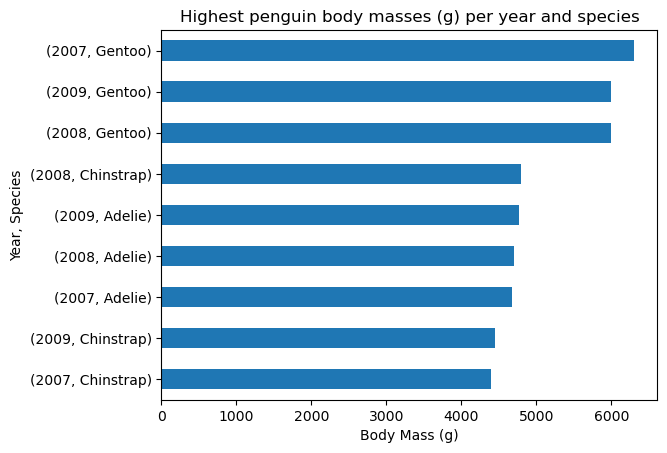

In [32]:
(penguins.groupby(['year','species'])['body_mass_g']
         .max()
         .sort_values()
         .plot(kind='barh',
                title='Highest penguin body masses (g) per year and species',
                xlabel='Body Mass (g)',
                ylabel='Year, Species')
         )